In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\shiva\Downloads\blinkit_data.csv", encoding='latin1')

# Quick checks
print(df.head())      # first 5 rows
print(df.shape)       # rows and columns
df.info()             # data types
print(df.describe())  # statistics

  ï»¿Item Fat Content Item Identifier              Item Type  \
0             Regular           FDX32  Fruits and Vegetables   
1             Low Fat           NCB42     Health and Hygiene   
2             Regular           FDR28           Frozen Foods   
3             Regular           FDL50                 Canned   
4             Low Fat           DRI25            Soft Drinks   

   Outlet Establishment Year Outlet Identifier Outlet Location Type  \
0                       2012            OUT049               Tier 1   
1                       2022            OUT018               Tier 3   
2                       2010            OUT046               Tier 1   
3                       2000            OUT013               Tier 3   
4                       2015            OUT045               Tier 2   

  Outlet Size        Outlet Type  Item Visibility  Item Weight     Sales  \
0      Medium  Supermarket Type1         0.100014        15.10  145.4786   
1      Medium  Supermarket Type2    

# Check data type 

In [5]:
df.dtypes

ï»¿Item Fat Content           object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

# Data Cleaning 

In [7]:
df['ï»¿Item Fat Content'].unique()

array(['Regular', 'Low Fat', 'low fat', 'LF', 'reg'], dtype=object)

In [14]:
df.rename(columns={'ï»¿Item Fat Content':'Item Fat Content'},inplace = True)

In [15]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [20]:
df['Item Fat Content']=df['Item Fat Content'].replace({'low fat':'Low Fat','reg':'Regular'})

In [21]:
df['Item Fat Content'].unique()

array(['Regular', 'Low Fat', 'LF'], dtype=object)

In [22]:
df['Item Fat Content']=df['Item Fat Content'].replace({'LF':'Low Fat'})

In [23]:
df['Item Fat Content'].unique()

array(['Regular', 'Low Fat'], dtype=object)

# KP'I Requirement 

In [39]:
# total sale 
total_sales = df['Sales'].sum()
print('Total Sales',total_sales)

# Averge Sale
AVG_sales = df['Sales'].mean()
print('Averge Sale',AVG_sales)

#Number of item 
Count_sales = df['Sales'].count()
print('Count Sales',Count_sales)

# AVG_rating 
AVG_rating = df['Rating'].mean()
print('Averge of Rating',AVG_rating)


Total Sales 1201681.4808
Averge Sale 140.9927819781767
Count Sales 8523
Averge of Rating 3.965857092573038


# Charts Requirement for business purpose 

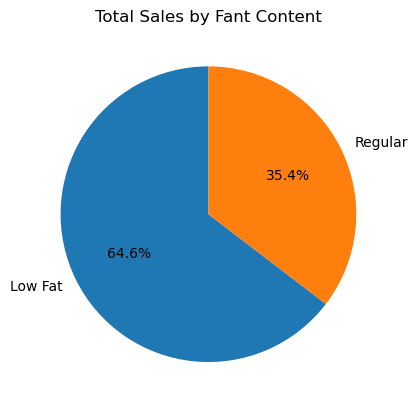

In [41]:
# Total Sales by Fat Content 
sale_fat= df.groupby('Item Fat Content')['Sales'].sum()
plt.pie(sale_fat,labels=sale_fat.index,autopct='%.1f%%',startangle=90)
plt.title('Total Sales by Fant Content')
plt.show()

# Total Sales by Item Type:


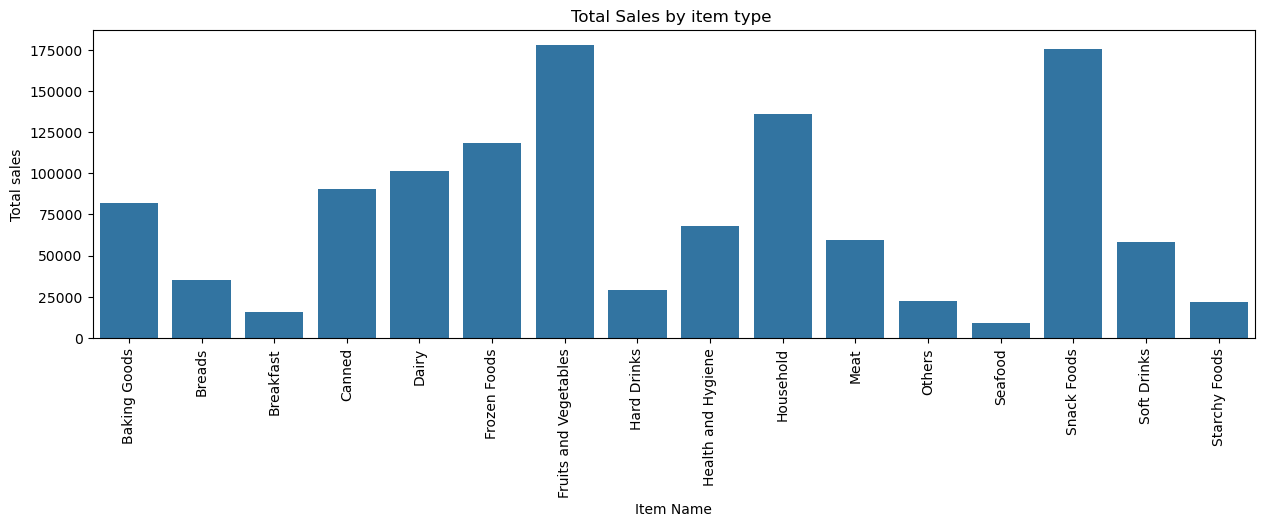

In [57]:
#Total Sales by item type 
plt.figure(figsize=(15,4))
Sales_item_type = df.groupby('Item Type')['Sales'].sum().reset_index()

sns.barplot(x ='Item Type',y='Sales',data =Sales_item_type)
plt.xlabel('Item Name')
plt.ylabel('Total sales')
plt.xticks(rotation=90)
plt.title('Total Sales by item type ')
plt.show()



In [58]:
df.head(2)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.1,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.8,115.3492,5.0


Item Fat Content          Regular      Low Fat
Outlet Location Type                          
Tier 1                121349.8994  215047.9126
Tier 2                138685.8682  254464.7734
Tier 3                165326.0348  306806.9924


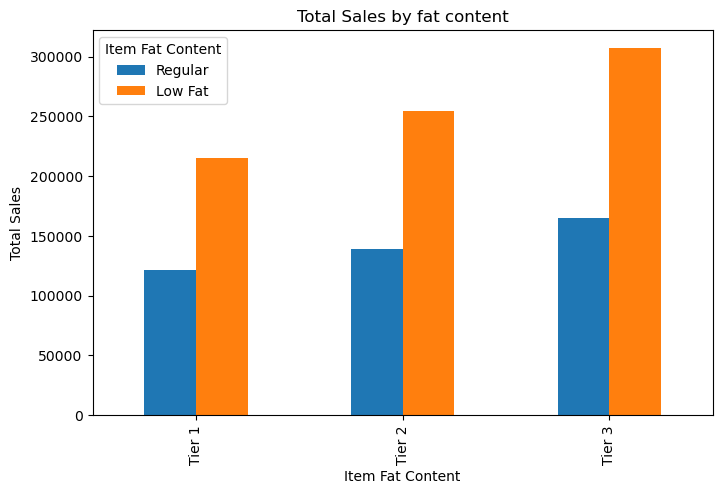

In [66]:
outlet_sale=df.groupby(['Outlet Location Type', 'Item Fat Content'])['Sales'].sum().unstack()
outlet_sale=outlet_sale[['Regular','Low Fat']]
print(outlet_sale)
outlet_sale.plot(kind='bar',stacked=False,figsize=(8,5))
plt.title('Total Sales by fat content')
plt.xlabel('Item Fat Content')
plt.ylabel('Total Sales')
plt.show()

# Total sales by outlet estabilsh 

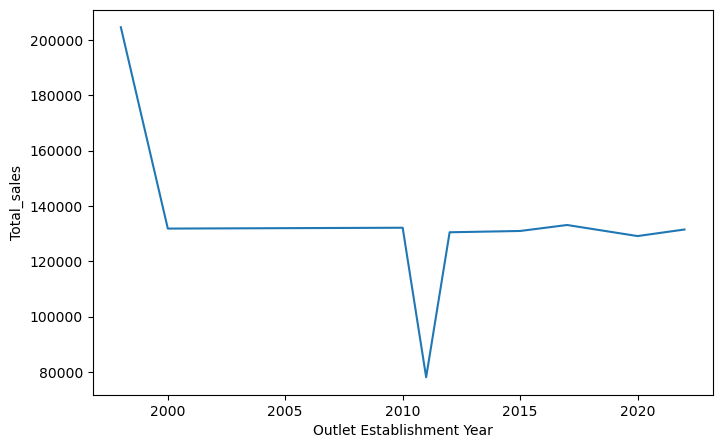

In [70]:
sale_outlet = df.groupby('Outlet Establishment Year')['Sales'].sum().reset_index()
plt.figure(figsize=(8,5))
sns.lineplot(x = 'Outlet Establishment Year',y='Sales',data = sale_outlet)
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total_sales')
plt.show()

In [67]:
df.head(2)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.1,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.8,115.3492,5.0


# Sales by outlet size

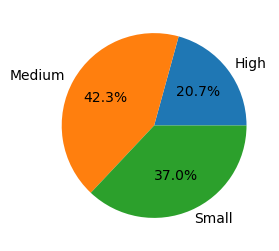

In [80]:
sale_outletsize = df.groupby('Outlet Size')['Sales'].sum().reset_index()
plt.figure(figsize=(4,3))
plt.pie(sale_outletsize['Sales'],labels=sale_outletsize['Outlet Size'],autopct='%1.1F%%')
plt.show()

# 6. Sales by Outlet Location:


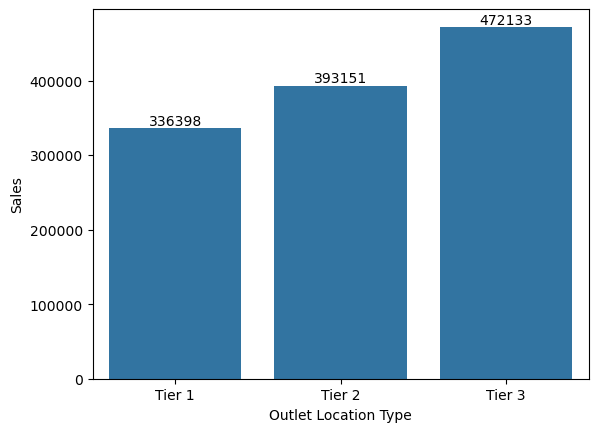

In [90]:
Sales_outlet_location = df.groupby('Outlet Location Type')['Sales'].sum().reset_index()
ax=sns.barplot(x='Outlet Location Type',y='Sales', data = Sales_outlet_location)
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

In [81]:
df.head(2)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.1,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.8,115.3492,5.0
